In [1]:
# 1. Import Required Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet (needs separate installation: pip install prophet)
try:
    from prophet import Prophet
except ImportError:
    print("Prophet not installed. Please run: pip install prophet")
    Prophet = None

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('/content/heart_rate.csv')
print("Dataset shape:", df.shape)
print("First 5 rows:\n", df.head())

Dataset shape: (1800, 4)
First 5 rows:
         T1       T2       T3       T4
0  84.2697  91.4634  60.4839  59.2885
1  84.2697  91.4634  60.4839  59.2885
2  84.0619  91.1834  60.4606  59.2885
3  85.6542  91.8788  60.3391  58.8973
4  87.2093  91.1772  60.0762  58.4359


In [3]:
# ==============================
# 3. Data Preprocessing
# ==============================
# Check missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Forward fill to handle missing values (time series continuity)
df.fillna(method='ffill', inplace=True)

# Ensure no missing values remain
if df.isnull().sum().any():
    df.fillna(method='bfill', inplace=True)  # backfill for any leading NaNs

# Create a datetime index (assuming readings every minute, starting from a fixed point)
# For simplicity, we create an hourly frequency starting from '2024-01-01'
date_rng = pd.date_range(start='2024-01-01', periods=len(df), freq='H')
df.set_index(date_rng, inplace=True)
print("\nData after preprocessing:\n", df.head())

# Normalize data for deep learning models (optional for ARIMA/Prophet)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

# Split into train (80%) and test (20%) – preserving temporal order
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]
train_scaled, test_scaled = df_scaled.iloc[:train_size], df_scaled.iloc[train_size:]

print(f"\nTrain size: {len(train)} | Test size: {len(test)}")


Missing values per column:
 T1      0
T2      0
T3    850
T4    909
dtype: int64

Data after preprocessing:
                           T1       T2       T3       T4
2024-01-01 00:00:00  84.2697  91.4634  60.4839  59.2885
2024-01-01 01:00:00  84.2697  91.4634  60.4839  59.2885
2024-01-01 02:00:00  84.0619  91.1834  60.4606  59.2885
2024-01-01 03:00:00  85.6542  91.8788  60.3391  58.8973
2024-01-01 04:00:00  87.2093  91.1772  60.0762  58.4359

Train size: 1440 | Test size: 360


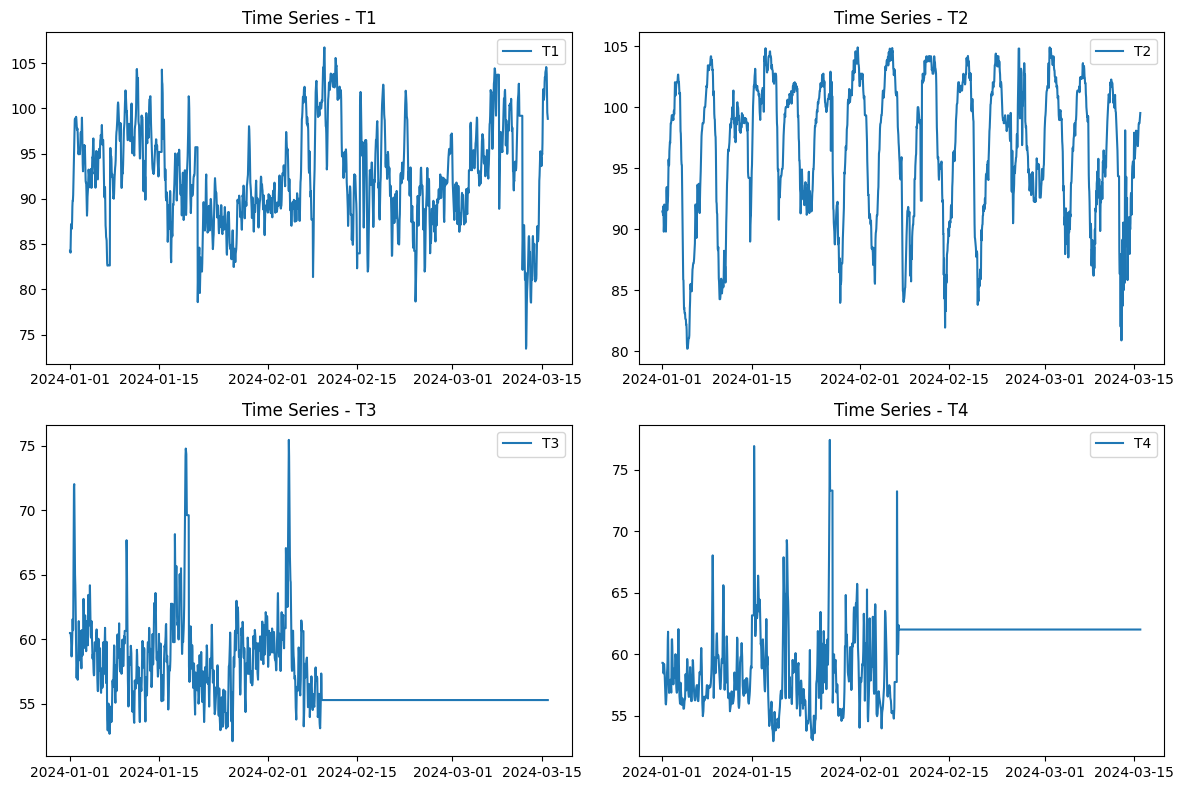

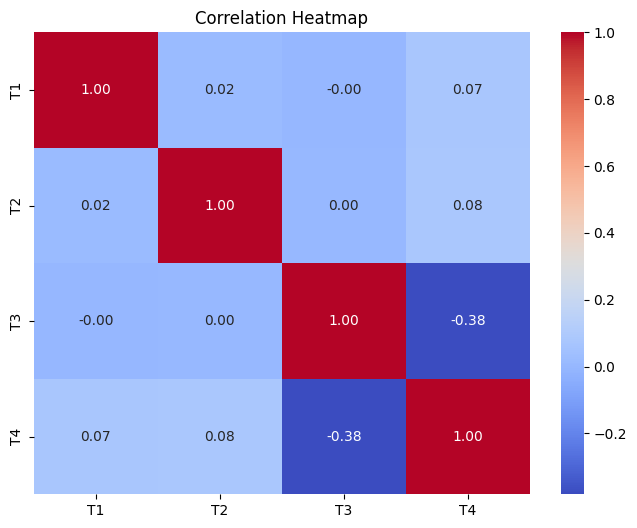

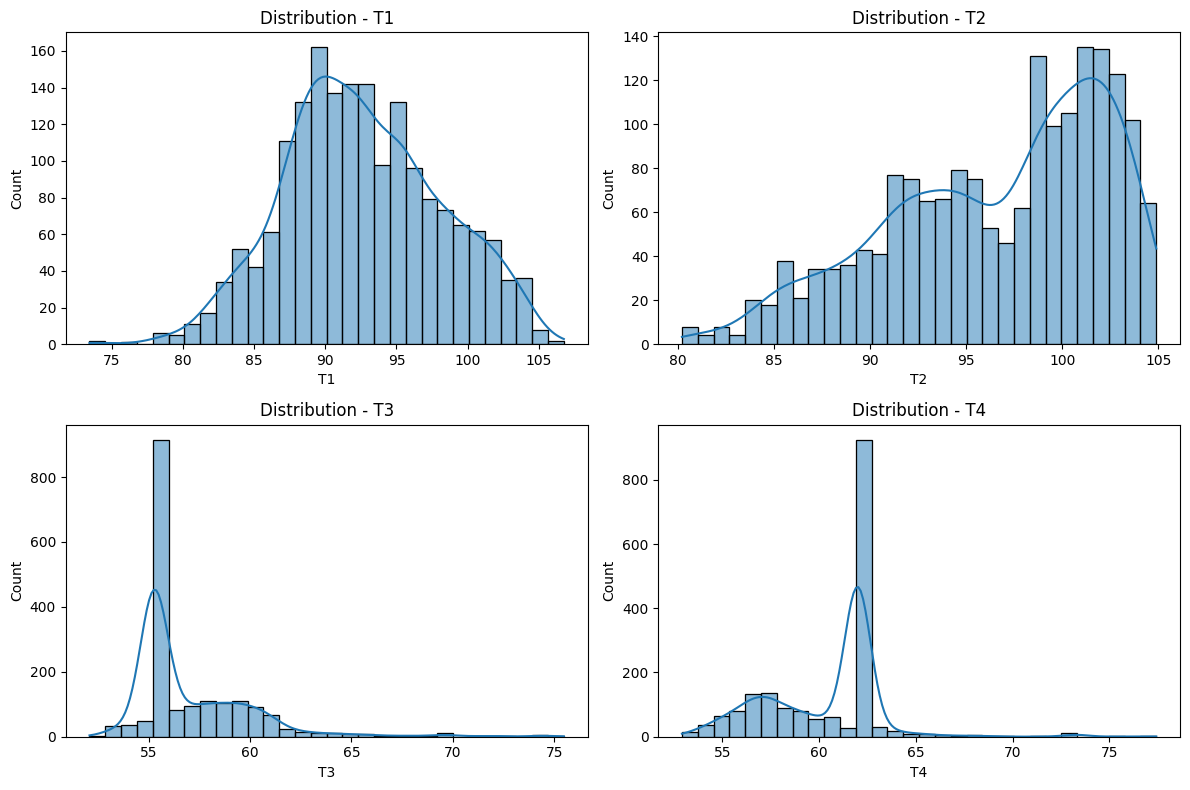

In [4]:
# ==============================
# 4. Exploratory Data Analysis
# ==============================
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 2, i)
    plt.plot(df.index, df[col], label=col)
    plt.title(f'Time Series - {col}')
    plt.legend()
plt.tight_layout()
plt.savefig('time_series_plots.png')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

# Distribution of heart rates
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution - {col}')
plt.tight_layout()
plt.savefig('distributions.png')
plt.show()


In [5]:

# ==============================
# 5. Helper Functions for Evaluation
# ==============================
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

def plot_actual_vs_predicted(y_true, y_pred, model_name, title_suffix=''):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true.index, y_true, label='Actual', color='blue')
    plt.plot(y_true.index, y_pred, label='Predicted', color='red', linestyle='--')
    plt.title(f'{model_name} - Actual vs Predicted {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{model_name}_forecast.png')
    plt.show()


ARIMA Model for T1
ADF Statistic: -4.3405
p-value: 0.0004
Series is stationary
                               SARIMAX Results                                
Dep. Variable:                     T1   No. Observations:                 1440
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -2325.186
Date:                Fri, 27 Mar 2026   AIC                           4664.373
Time:                        05:06:46   BIC                           4701.279
Sample:                    01-01-2024   HQIC                          4678.150
                         - 02-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.3236      0.844    109.336      0.000      90.669      93.979
ar.L1          1.3809      0.008    164.420      0.

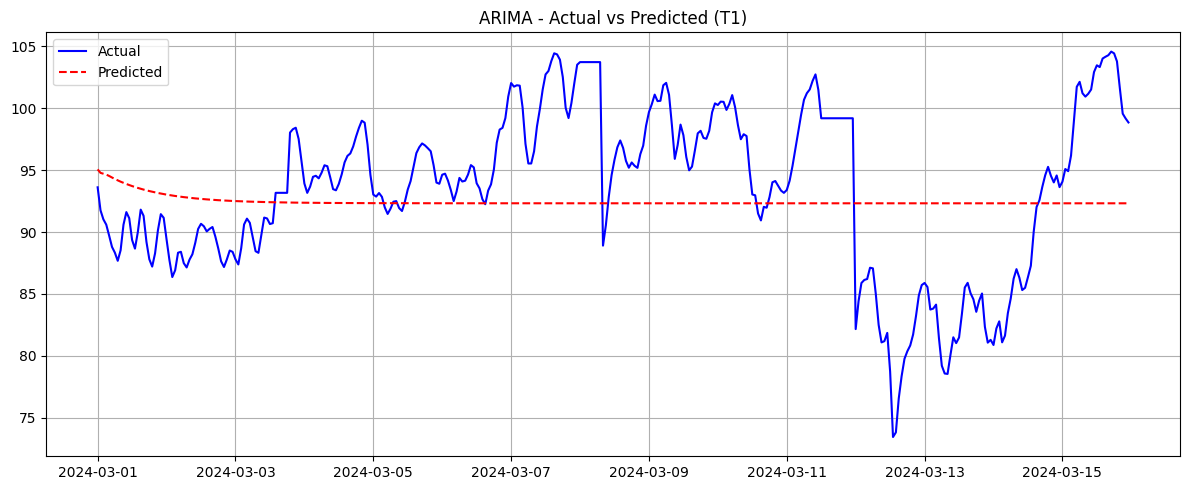

In [6]:
# ==============================
# 6. ARIMA Model (on T1)
# ==============================
print("\n" + "="*50)
print("ARIMA Model for T1")
print("="*50)

# For simplicity, we focus on one column: T1
target_col = 'T1'
train_series = train[target_col]
test_series = test[target_col]

# Check stationarity
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Series is stationary")
        return 0
    else:
        print("Series is non-stationary")
        return 1

d = check_stationarity(train_series)
if d > 0:
    # Apply differencing once
    train_series_diff = train_series.diff().dropna()
    d = 1
    check_stationarity(train_series_diff)

# Fit ARIMA (order p,d,q determined manually or via auto_arima)
# Here we use a simple (5,1,0) – you may tune using ACF/PACF or auto_arima
arima_order = (5, d, 0)
model_arima = ARIMA(train_series, order=arima_order)
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

# Forecast on test period
forecast_arima = model_arima_fit.forecast(steps=len(test_series))
forecast_arima.index = test_series.index  # align index

# Evaluate
mae_arima, rmse_arima, mape_arima = calculate_metrics(test_series, forecast_arima)
print(f"ARIMA -> MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}%")

plot_actual_vs_predicted(test_series, forecast_arima, 'ARIMA', f'({target_col})')


Prophet Model for T1
Prophet -> MAE: 6.81, RMSE: 8.14, MAPE: 7.11%


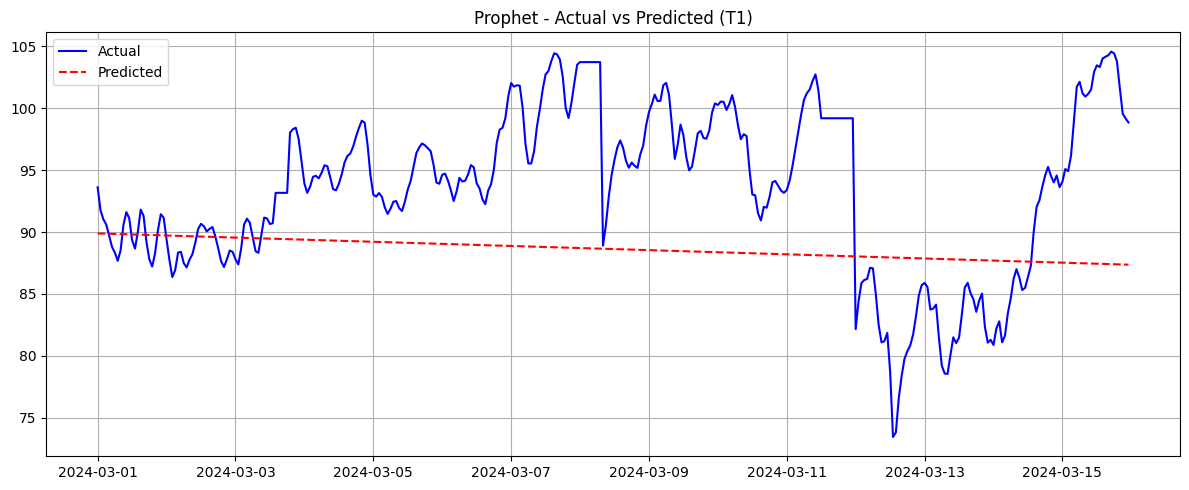

In [7]:
# ==============================
# 7. Prophet Model (on T1)
# ==============================
if Prophet is not None:
    print("\n" + "="*50)
    print("Prophet Model for T1")
    print("="*50)

    # Prepare data in Prophet format
    prophet_train = pd.DataFrame({
        'ds': train_series.index,
        'y': train_series.values
    })

    # Fit model
    model_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model_prophet.fit(prophet_train)

    # Create future dataframe for test period
    future = model_prophet.make_future_dataframe(periods=len(test_series), freq='H', include_history=False)
    forecast = model_prophet.predict(future)
    forecast_prophet = forecast.set_index('ds')['yhat'].loc[test_series.index]

    # Evaluate
    mae_prophet, rmse_prophet, mape_prophet = calculate_metrics(test_series, forecast_prophet)
    print(f"Prophet -> MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2f}%")

    plot_actual_vs_predicted(test_series, forecast_prophet, 'Prophet', f'({target_col})')
else:
    mae_prophet = rmse_prophet = mape_prophet = None

In [8]:
!pip install prophet

In [9]:
from prophet import Prophet

In [10]:
import pandas as pd


LSTM Model for T1
LSTM -> MAE: 2.34, RMSE: 3.26, MAPE: 2.66%


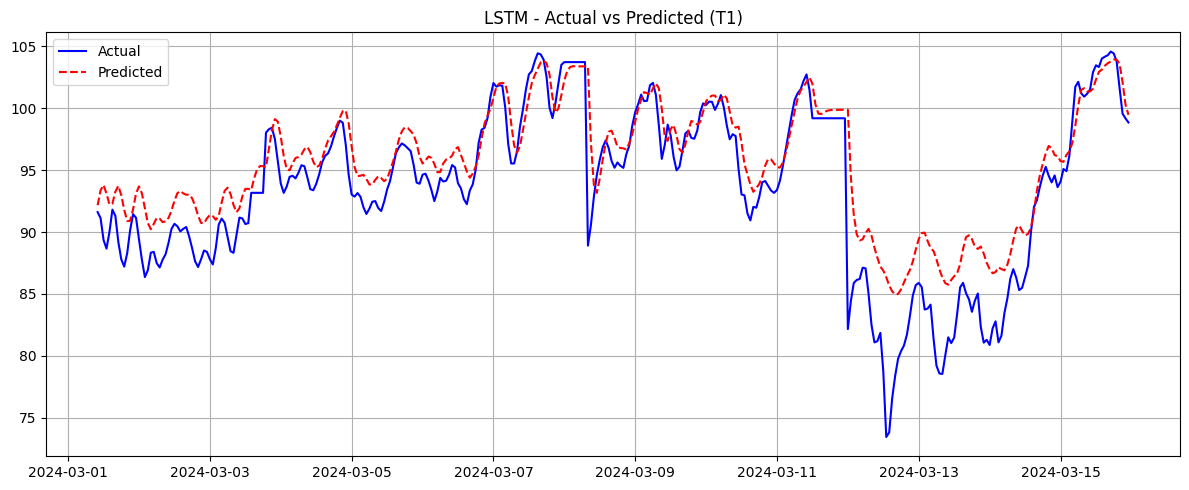

In [11]:
# ==============================
# 8. LSTM Model (on T1)
# ==============================
print("\n" + "="*50)
print("LSTM Model for T1")
print("="*50)

# Prepare sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10  # number of past time steps to use

# Use scaled data for deep learning
train_scaled_t1 = train_scaled[target_col].values.reshape(-1, 1)
test_scaled_t1 = test_scaled[target_col].values.reshape(-1, 1)

# Scale target for inverse transform later
scaler_y = MinMaxScaler()
scaler_y.fit(train[[target_col]])

X_train, y_train = create_sequences(train_scaled_t1, seq_length)
X_test, y_test = create_sequences(test_scaled_t1, seq_length)

# Reshape for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM model
model_lstm = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# Predict
y_pred_lstm_scaled = model_lstm.predict(X_test, verbose=0)

# Inverse transform
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Align indices (since we lost first seq_length points from test)
test_actual_aligned = test_series.iloc[seq_length:]
y_pred_lstm_series = pd.Series(y_pred_lstm.flatten(), index=test_actual_aligned.index)

# Evaluate
mae_lstm, rmse_lstm, mape_lstm = calculate_metrics(test_actual_aligned, y_pred_lstm_series)
print(f"LSTM -> MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}%")

plot_actual_vs_predicted(test_actual_aligned, y_pred_lstm_series, 'LSTM', f'({target_col})')


GRU Model for T1
GRU -> MAE: 3.98, RMSE: 5.12, MAPE: 4.46%


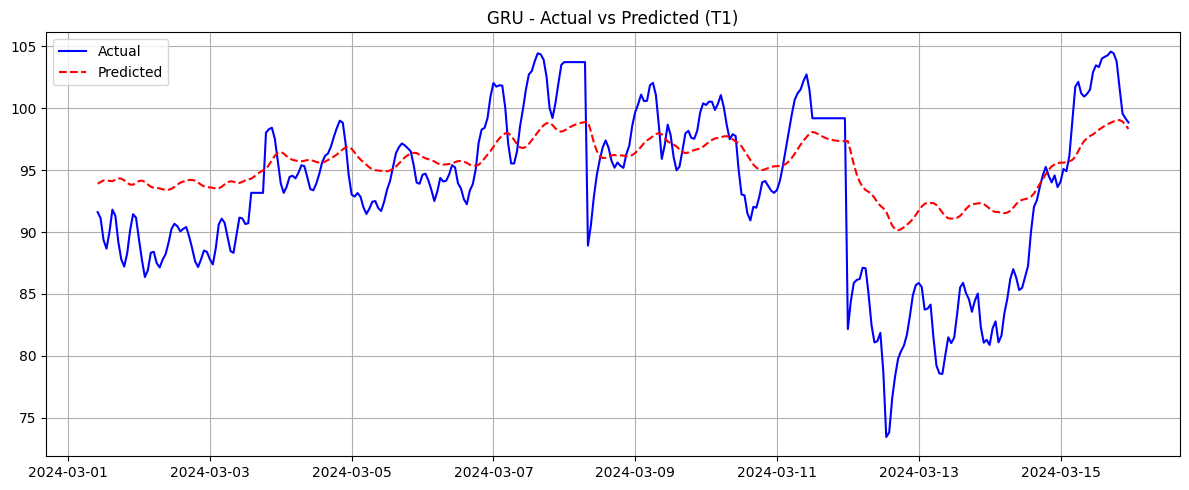

In [12]:
# 9. GRU Model (on T1)
# ==============================
print("\n" + "="*50)
print("GRU Model for T1")
print("="*50)

# Build GRU model
model_gru = Sequential([
    GRU(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    GRU(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')

# Train
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# Predict
y_pred_gru_scaled = model_gru.predict(X_test, verbose=0)
y_pred_gru = scaler_y.inverse_transform(y_pred_gru_scaled)
y_pred_gru_series = pd.Series(y_pred_gru.flatten(), index=test_actual_aligned.index)

# Evaluate
mae_gru, rmse_gru, mape_gru = calculate_metrics(test_actual_aligned, y_pred_gru_series)
print(f"GRU -> MAE: {mae_gru:.2f}, RMSE: {rmse_gru:.2f}, MAPE: {mape_gru:.2f}%")

plot_actual_vs_predicted(test_actual_aligned, y_pred_gru_series, 'GRU', f'({target_col})')



Model Performance Comparison
  Model      MAE     RMSE  MAPE (%)
  ARIMA 5.594502 6.702387  6.050327
Prophet 6.806240 8.142719  7.107913
   LSTM 2.341236 3.260032  2.656729
    GRU 3.980252 5.119892  4.461453


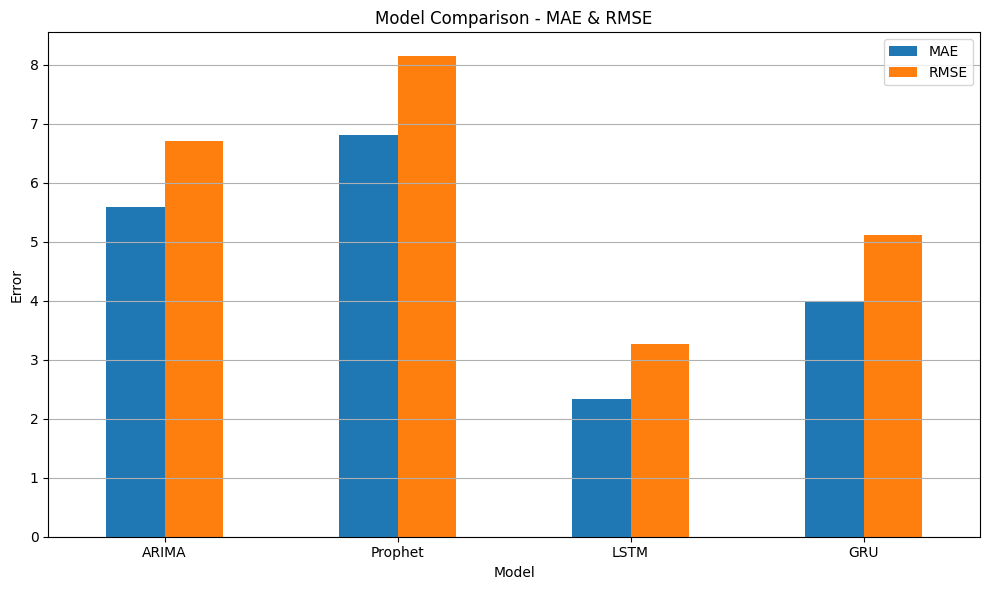

In [13]:
# 10. Model Comparison Table
# ==============================
print("\n" + "="*50)
print("Model Performance Comparison")
print("="*50)

comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'LSTM', 'GRU'],
    'MAE': [mae_arima, mae_prophet, mae_lstm, mae_gru],
    'RMSE': [rmse_arima, rmse_prophet, rmse_lstm, rmse_gru],
    'MAPE (%)': [mape_arima, mape_prophet, mape_lstm, mape_gru]
})
print(comparison.to_string(index=False))

# Bar chart comparison
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison - MAE & RMSE')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()



Anomaly Detection (Tachycardia >100, Bradycardia <60)
Number of tachycardia events (>100): 205
Number of bradycardia events (<60): 0


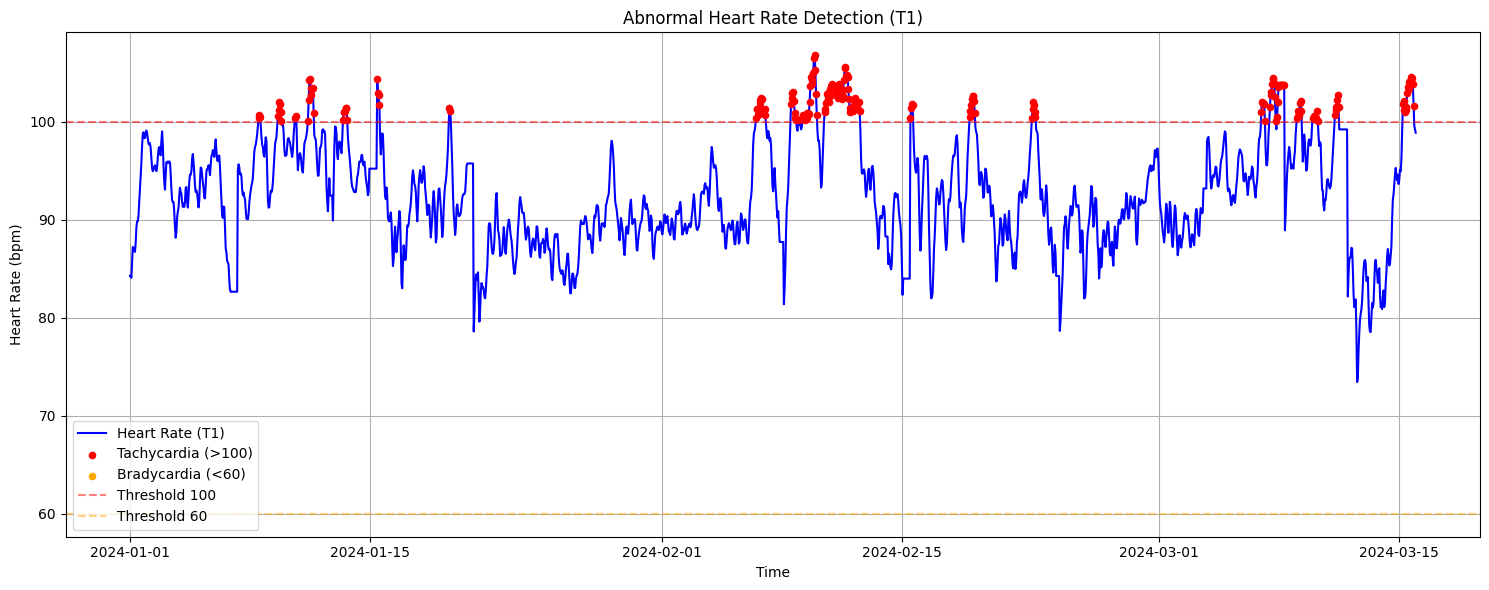

In [14]:
# 11. Early Abnormal Heart Rate Detection
# ==============================
print("\n" + "="*50)
print("Anomaly Detection (Tachycardia >100, Bradycardia <60)")
print("="*50)

# Use the entire dataset or predictions to detect anomalies
full_series = df[target_col]  # original T1

# Define thresholds
tachy_threshold = 100
brady_threshold = 60

anomalies_tachy = full_series[full_series > tachy_threshold]
anomalies_brady = full_series[full_series < brady_threshold]

print(f"Number of tachycardia events (>100): {len(anomalies_tachy)}")
print(f"Number of bradycardia events (<60): {len(anomalies_brady)}")

# Plot with anomalies highlighted
plt.figure(figsize=(15, 6))
plt.plot(full_series.index, full_series, label='Heart Rate (T1)', color='blue')
plt.scatter(anomalies_tachy.index, anomalies_tachy, color='red', label='Tachycardia (>100)', s=20, zorder=5)
plt.scatter(anomalies_brady.index, anomalies_brady, color='orange', label='Bradycardia (<60)', s=20, zorder=5)
plt.axhline(y=tachy_threshold, color='red', linestyle='--', alpha=0.5, label='Threshold 100')
plt.axhline(y=brady_threshold, color='orange', linestyle='--', alpha=0.5, label='Threshold 60')
plt.title('Abnormal Heart Rate Detection (T1)')
plt.xlabel('Time')
plt.ylabel('Heart Rate (bpm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('anomaly_detection.png')
plt.show()



Future Forecasting using LSTM (next 24 hours)


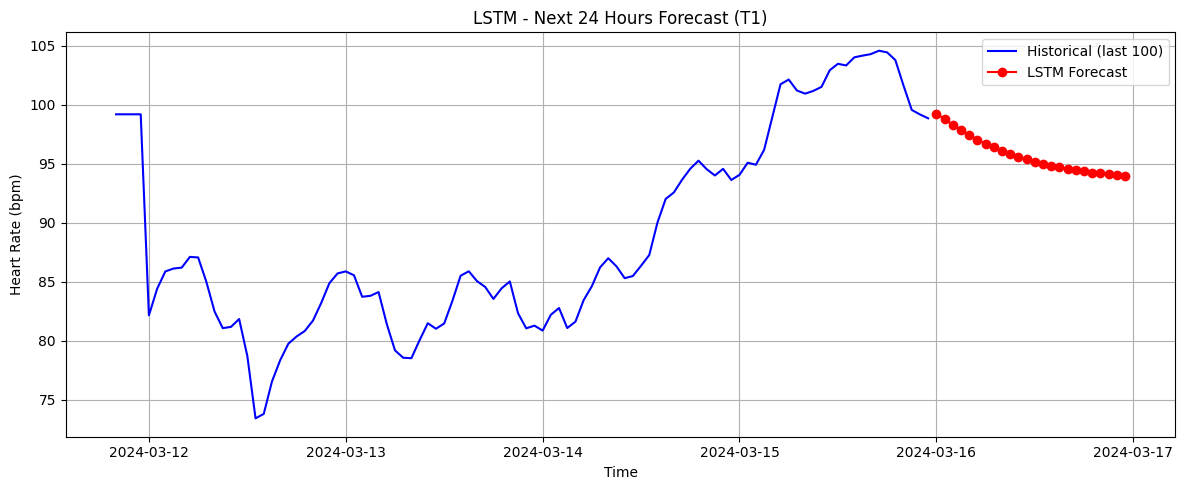

In [15]:
# 12. Future Forecasting Example (LSTM)
# ==============================
print("\n" + "="*50)
print("Future Forecasting using LSTM (next 24 hours)")
print("="*50)

# Use the last 'seq_length' points of the full scaled T1 to predict next steps
last_sequence = scaled_data[:, 0][-seq_length:]  # last seq_length of T1
last_sequence_scaled = last_sequence.reshape((1, seq_length, 1))

future_steps = 24
future_predictions_scaled = []

current_seq = last_sequence_scaled.copy()
for _ in range(future_steps):
    pred = model_lstm.predict(current_seq, verbose=0)[0, 0]
    future_predictions_scaled.append(pred)
    # Update sequence: remove first, append new prediction
    new_seq = np.append(current_seq[0, 1:, 0], pred).reshape((1, seq_length, 1))
    current_seq = new_seq

# Inverse transform
future_predictions = scaler_y.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# Create future time index
last_time = df.index[-1]
future_index = pd.date_range(start=last_time, periods=future_steps+1, freq='H')[1:]

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index[-100:], df[target_col].iloc[-100:], label='Historical (last 100)', color='blue')
plt.plot(future_index, future_predictions, label='LSTM Forecast', color='red', marker='o')
plt.title(f'LSTM - Next {future_steps} Hours Forecast (T1)')
plt.xlabel('Time')
plt.ylabel('Heart Rate (bpm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('future_forecast_lstm.png')
plt.show()